# ISIC 2024 - Data Exploration

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

DATA_DIR = '../data'

## Load data
Only keeping the columns that are also in the test set (plus `target`), the rest leak the diagnosis.

In [64]:
train = pd.read_csv(DATA_DIR + '/train-metadata.csv', low_memory=False)
test = pd.read_csv(DATA_DIR + '/test-metadata.csv')
target = train['target']

# only care about columns in both and the target
train = train[test.columns]
train['target'] = target

In [65]:
train.head()

,isic_id,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license,target
0,ISIC_0015670,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,16.261975,...,2.036195,2.637780,0.590476,85,-182.703552,613.493652,-42.427948,Memorial Sloan Kettering Cancer Center,CC-BY,0
1,ISIC_0015845,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,25.364740,...,0.853227,3.912844,0.285714,55,-0.078308,1575.687000,57.174500,Memorial Sloan Kettering Cancer Center,CC-BY,0
2,ISIC_0015864,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,17.128170,...,1.743651,1.950777,0.361905,105,123.649700,1472.010000,232.908900,Memorial Sloan Kettering Cancer Center,CC-BY,0
3,ISIC_0015902,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,12.164757,...,1.258541,1.573733,0.209581,130,-141.024780,1442.185791,58.359802,ACEMID MIA,CC-0,0
4,ISIC_0024200,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,20.057470,...,2.085409,2.480509,0.313433,20,-72.315640,1488.720000,21.428960,Memorial Sloan Kettering Cancer Center,CC-BY,0


In [66]:
train.describe()

,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,...,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,target
count,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000
mean,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,60.996869,...,11.878891,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.000980
std,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,5.631909,...,5.919302,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.031288
min,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,28.436490,...,2.579237,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.000000
25%,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,57.297630,...,8.338364,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.000000
50%,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,61.109173,...,10.015440,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.000000
75%,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,64.905025,...,13.209100,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.000000
max,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,130.983300,...,102.493900,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,1.000000


## Feature distributions

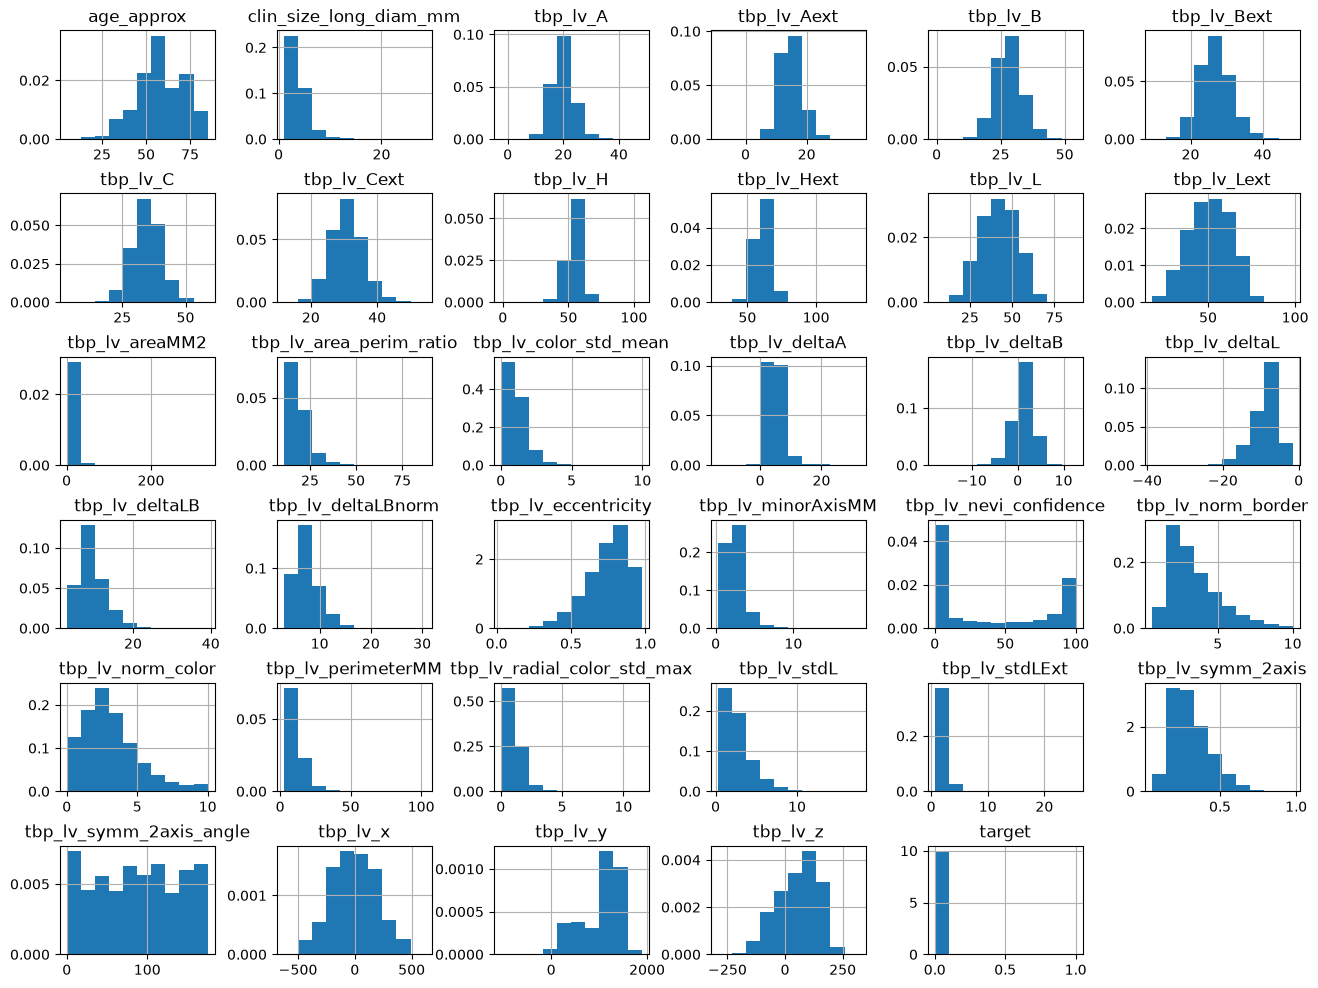

In [67]:
axes = train.hist(
    figsize=(16, 12),
    density=True
)

plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

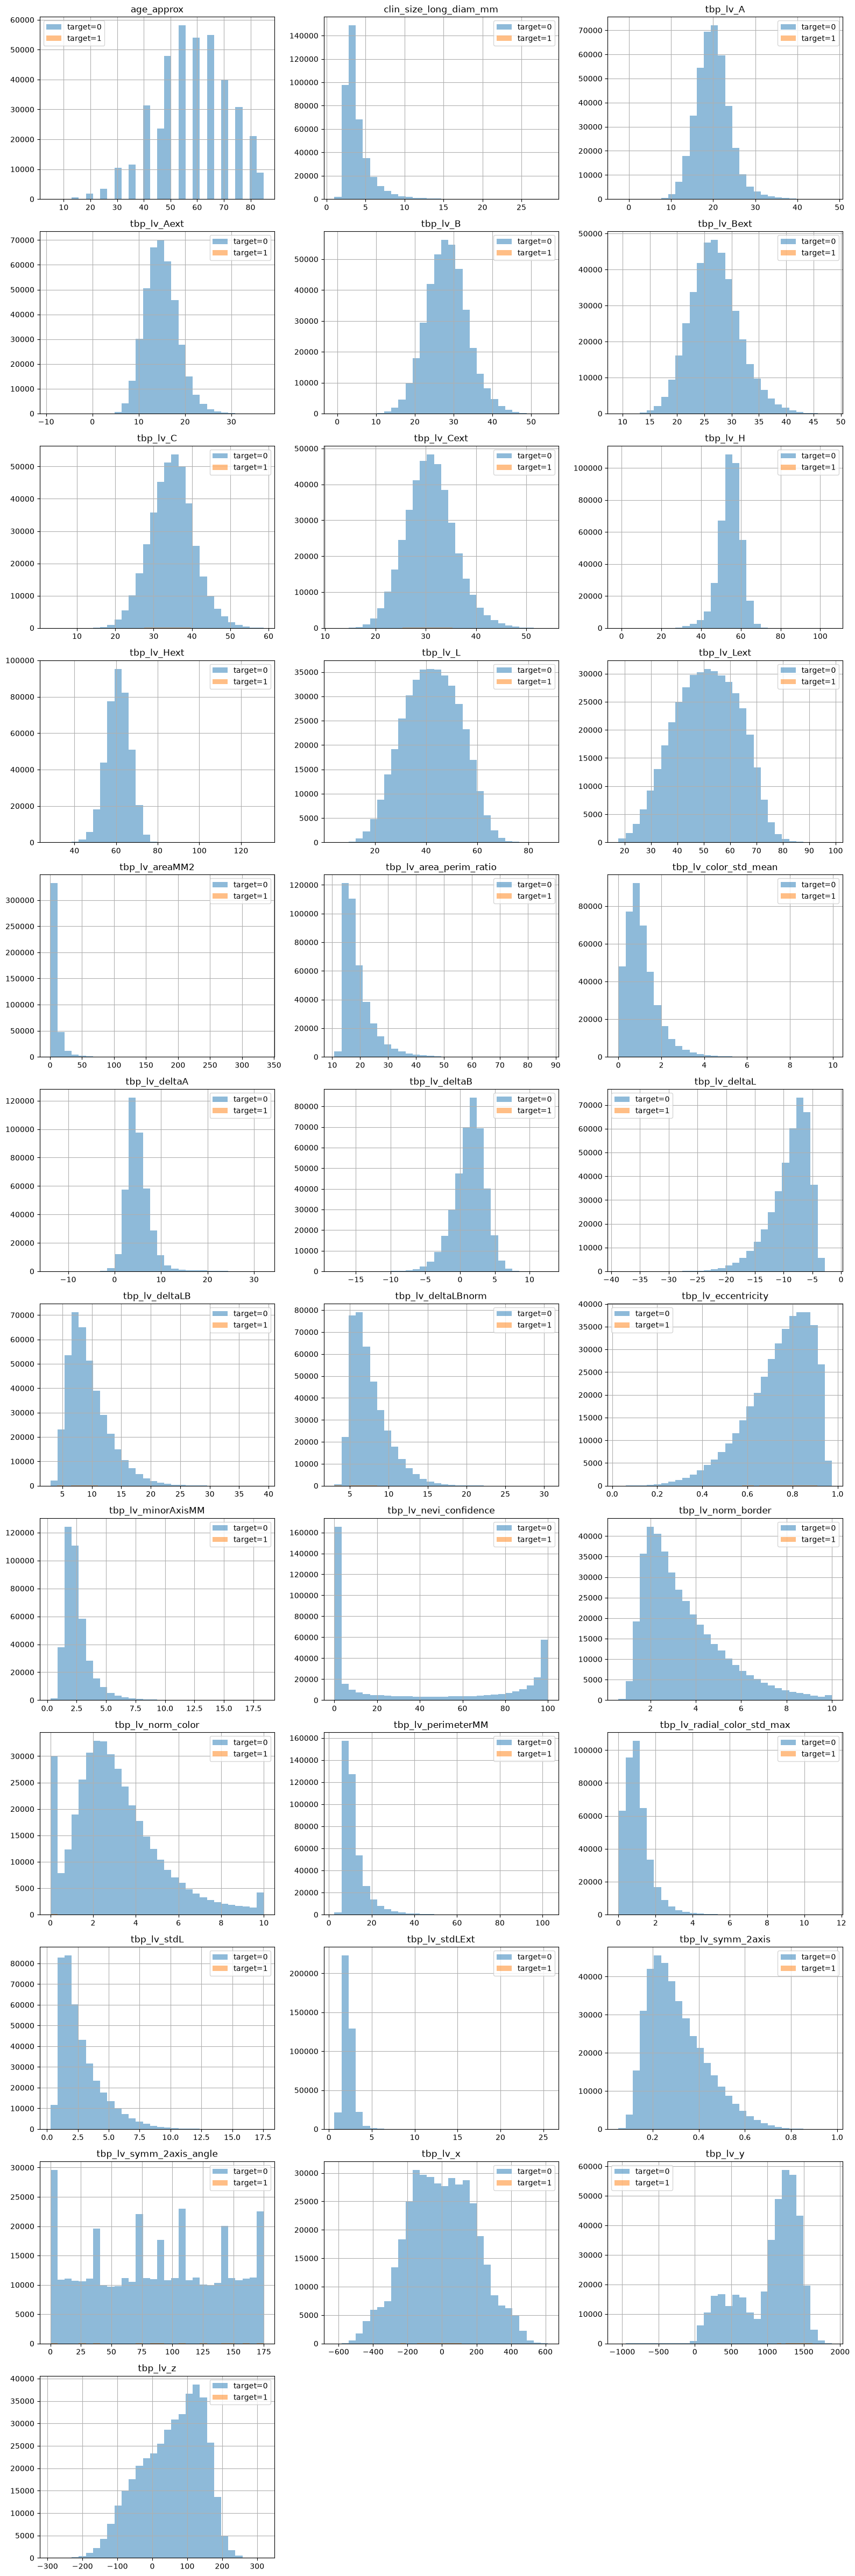

In [68]:
features = train.select_dtypes(include='number').columns.drop('target')

fig, axes = plt.subplots(
    nrows=(len(features) + 2) // 3,
    ncols=3,
    figsize=(16, 4 * ((len(features) + 2) // 3))
)

axes = axes.flatten()

for ax, col in zip(axes, features):
    for target_value in train['target'].unique():
        train.loc[train['target'] == target_value, col].hist(
            ax=ax,
            alpha=0.5,
            bins=30,
            label=f'target={target_value}'
        )

    ax.set_title(col)
    ax.legend()

for ax in axes[len(features):]:
    ax.remove()

plt.tight_layout()
plt.show()

Text(0.5, 0.98, '')

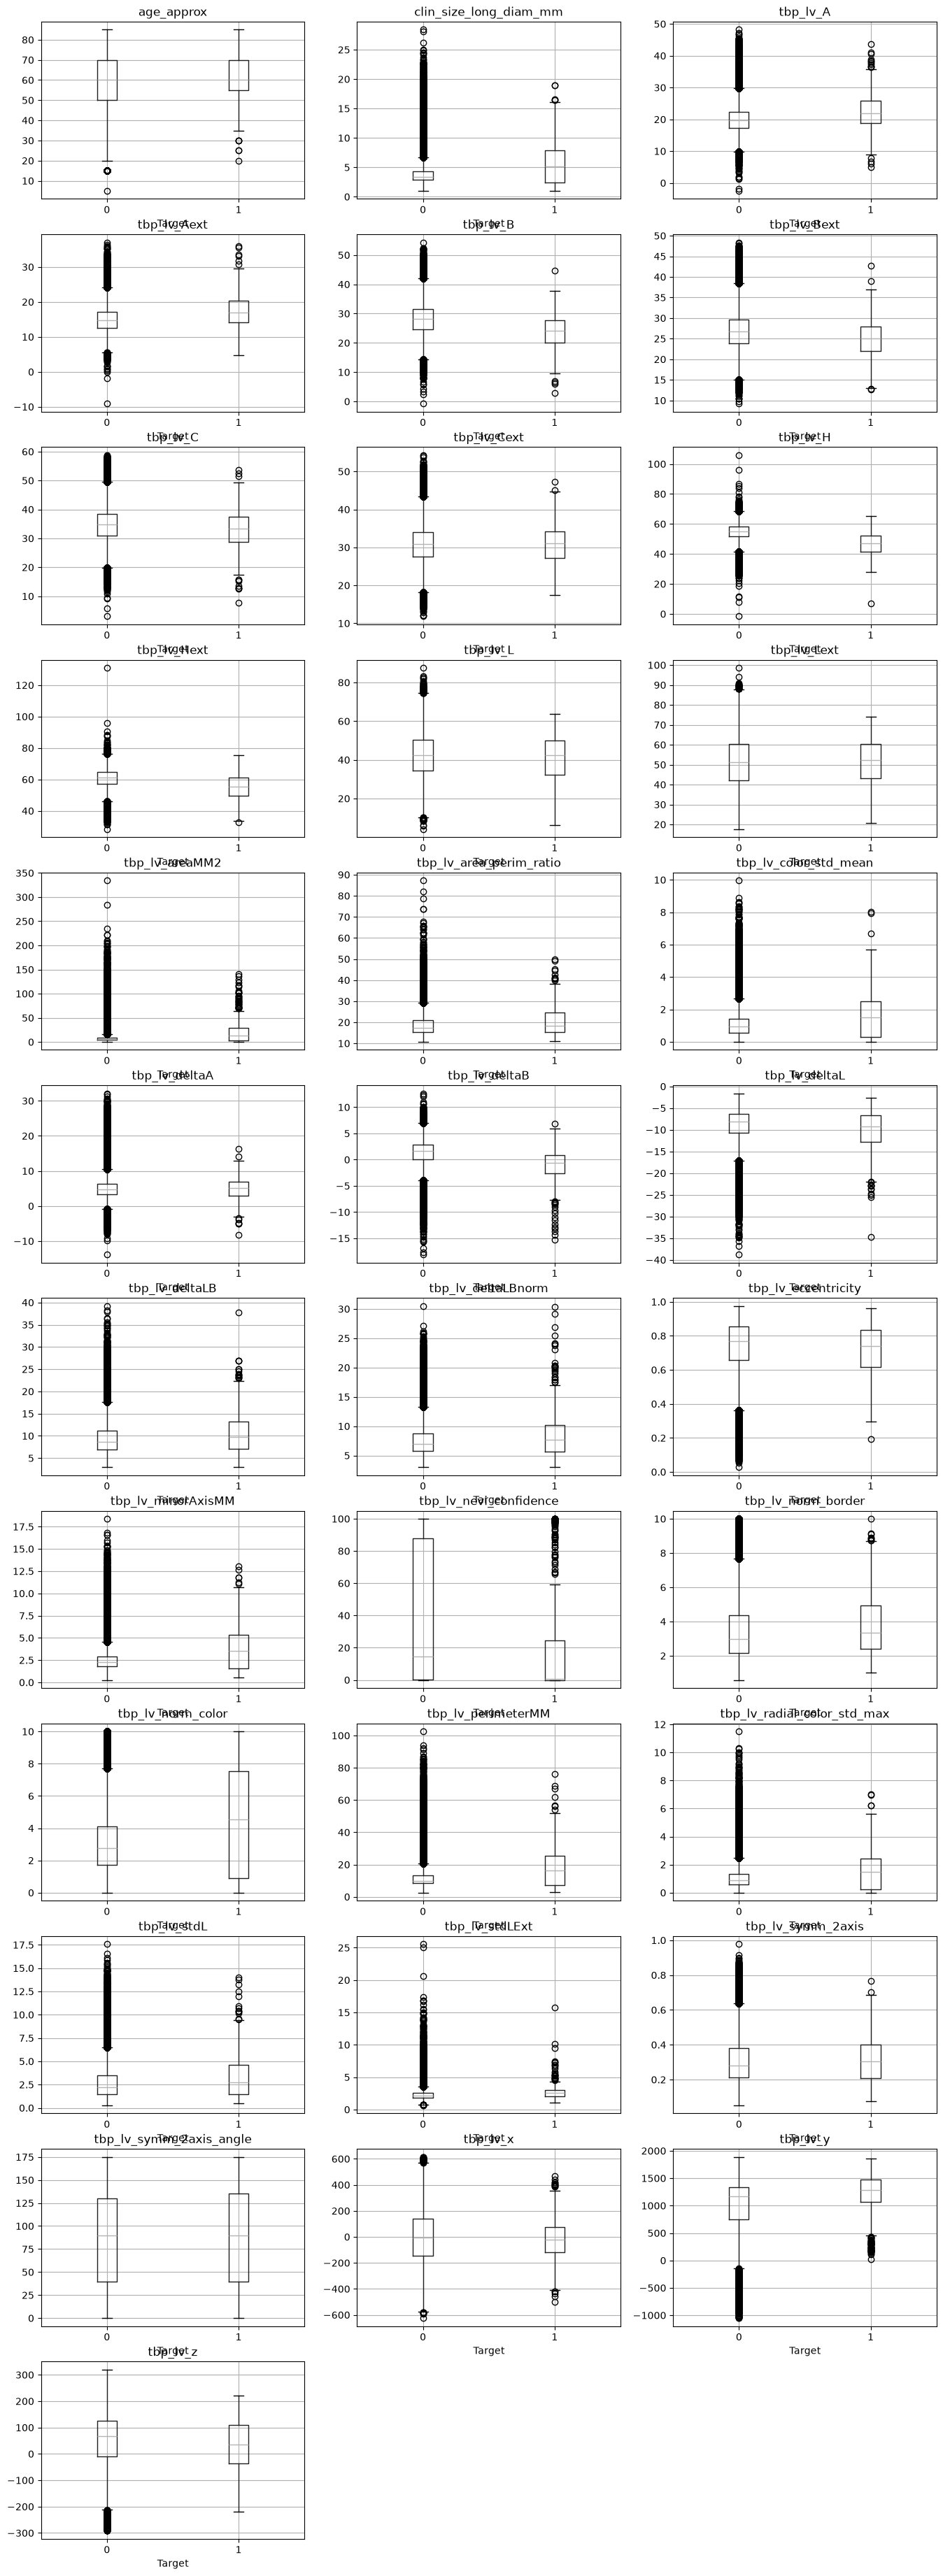

In [69]:
features = train.select_dtypes(include='number').columns.drop('target')

fig, axes = plt.subplots(
    (len(features) + 2) // 3,
    3,
    figsize=(16, 4 * ((len(features) + 2) // 3))
)

axes = axes.flatten()

for ax, col in zip(axes, features):
    train.boxplot(column=col, by='target', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Target')

for ax in axes[len(features):]:
    ax.remove()

plt.suptitle('')

## Test set, sex and patients

In [70]:
test.head()

,isic_id,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license
0,ISIC_0015657,IP_6074337,45.0,male,posterior torso,2.70,TBP tile: close-up,3D: XP,22.80433,20.007270,...,0.304827,1.281532,2.299935,0.479339,20,-155.06510,1511.222000,113.980100,Memorial Sloan Kettering Cancer Center,CC-BY
1,ISIC_0015729,IP_1664139,35.0,female,lower extremity,2.52,TBP tile: close-up,3D: XP,16.64867,9.657964,...,0.000000,1.271940,2.011223,0.426230,25,-112.36924,629.535889,-15.019287,"Frazer Institute, The University of Queensland...",CC-BY
2,ISIC_0015740,IP_7142616,65.0,male,posterior torso,3.16,TBP tile: close-up,3D: XP,24.25384,19.937380,...,0.230742,1.080308,2.705857,0.366071,110,-84.29282,1303.978000,-28.576050,FNQH Cairns,CC-BY


In [71]:
test.describe()

,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,...,tbp_lv_norm_color,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,48.333333,2.793333,21.235613,16.534205,30.055107,27.650733,36.939135,32.498746,54.900061,59.695153,...,0.621704,7.952809,0.178523,1.211260,2.339005,0.423880,51.666667,-117.242387,1148.245296,23.461588
std,15.275252,0.330051,4.037983,5.955101,1.508777,0.679182,1.795292,2.930254,6.153928,9.525959,...,0.578214,1.531253,0.158981,0.113509,0.348961,0.056670,50.579970,35.636913,461.012045,78.683844
min,35.000000,2.520000,16.648670,9.657964,28.384120,27.043640,35.467806,29.169579,51.220960,53.505430,...,0.000000,6.340311,0.000000,1.080308,2.011223,0.366071,20.000000,-155.065100,629.535889,-28.576050
25%,40.000000,2.610000,19.726500,14.797672,29.423900,27.283979,35.938953,31.404790,51.347845,54.210420,...,0.360870,7.235590,0.115371,1.176124,2.155579,0.396150,22.500000,-133.717170,966.756944,-21.797669
50%,45.000000,2.700000,22.804330,19.937380,30.463680,27.524318,36.410100,33.640000,51.474730,54.915410,...,0.721739,8.130868,0.230742,1.271940,2.299935,0.426230,25.000000,-112.369240,1303.978000,-15.019287
75%,55.000000,2.930000,23.529085,19.972325,30.890600,27.954279,37.674800,34.163330,56.739612,62.790014,...,0.932557,8.759058,0.267784,1.276736,2.502896,0.452784,67.500000,-98.331030,1407.600000,49.480406
max,65.000000,3.160000,24.253840,20.007270,31.317520,28.384240,38.939500,34.686660,62.004494,70.664619,...,1.143374,9.387248,0.304827,1.281532,2.705857,0.479339,110.000000,-84.292820,1511.222000,113.980100


In [72]:
train['sex'] = train['sex'].astype("category")

In [73]:
train['sex']

0           male
1           male
2           male
3           male
4           male
           ...  
401054      male
401055      male
401056    female
401057    female
401058      male
Name: sex, Length: 401059, dtype: category
Categories (2, str): ['female', 'male']

In [74]:
train.groupby('sex')['target'].value_counts()

sex     target
female  0         123887
        1            109
male    0         265272
        1            274
Name: count, dtype: int64

In [75]:
train['patient_id']

0         IP_1235828
1         IP_8170065
2         IP_6724798
3         IP_4111386
4         IP_8313778
             ...    
401054    IP_1140263
401055    IP_5678181
401056    IP_0076153
401057    IP_5231513
401058    IP_6426047
Name: patient_id, Length: 401059, dtype: str

In [76]:
test['patient_id']

0    IP_6074337
1    IP_1664139
2    IP_7142616
Name: patient_id, dtype: str

## Class balance

In [78]:
train['target'].value_counts()

target
0    400666
1       393
Name: count, dtype: int64

## Single feature AUC
AUC of each numeric feature on its own. 0.5 = no signal, the further from 0.5 the stronger (below 0.5 means lower values = malignant).

In [83]:
numeric_cols = train.select_dtypes(include='number').columns.drop('target')

auc_scores = {}

for col in numeric_cols:
    temp = train[['target', col]].dropna()

    # skip columns with no variation
    if temp[col].nunique() < 2:
        continue

    auc_scores[col] = sklearn.metrics.roc_auc_score(
        temp['target'],
        temp[col]
    )

pd.Series(auc_scores).sort_values(ascending=False)

tbp_lv_stdLExt                 0.662190
tbp_lv_Aext                    0.658557
tbp_lv_A                       0.638246
tbp_lv_minorAxisMM             0.627197
tbp_lv_perimeterMM             0.623109
tbp_lv_areaMM2                 0.617991
tbp_lv_radial_color_std_max    0.615952
tbp_lv_norm_color              0.615556
tbp_lv_y                       0.614126
clin_size_long_diam_mm         0.610390
tbp_lv_color_std_mean          0.609834
age_approx                     0.570574
tbp_lv_deltaLB                 0.564007
tbp_lv_stdL                    0.560271
tbp_lv_norm_border             0.553141
tbp_lv_deltaLBnorm             0.549210
tbp_lv_area_perim_ratio        0.543227
tbp_lv_symm_2axis              0.521311
tbp_lv_symm_2axis_angle        0.507648
tbp_lv_deltaA                  0.507088
tbp_lv_Lext                    0.502388
tbp_lv_Cext                    0.498643
tbp_lv_L                       0.476897
tbp_lv_x                       0.475735
tbp_lv_eccentricity            0.447214


In [84]:
numeric_cols = train.select_dtypes(include='number').columns.drop('target')

results = []

for col in numeric_cols:
    temp = train[['target', col]].dropna()

    if temp[col].nunique() < 2:
        continue

    auc = sklearn.metrics.roc_auc_score(temp['target'], temp[col])

    results.append({
        'feature': col,
        'auc': auc,
        'auc_strength': abs(auc - 0.5),
        'flipped_auc': max(auc, 1 - auc),
        'direction': 'higher = malignant' if auc > 0.5 else 'lower = malignant'
    })

auc_scores = (
    pd.DataFrame(results)
    .sort_values('auc_strength', ascending=False)
    .reset_index(drop=True)
)

auc_scores

,feature,auc,auc_strength,flipped_auc,direction
0,tbp_lv_H,0.194739,0.305261,0.805261,lower = malignant
1,tbp_lv_deltaB,0.245922,0.254078,0.754078,lower = malignant
2,tbp_lv_Hext,0.280484,0.219516,0.719516,lower = malignant
3,tbp_lv_B,0.288012,0.211988,0.711988,lower = malignant
4,tbp_lv_stdLExt,0.662190,0.162190,0.662190,higher = malignant
5,tbp_lv_Aext,0.658557,0.158557,0.658557,higher = malignant
6,tbp_lv_nevi_confidence,0.354272,0.145728,0.645728,lower = malignant
7,tbp_lv_A,0.638246,0.138246,0.638246,higher = malignant
8,tbp_lv_minorAxisMM,0.627197,0.127197,0.627197,higher = malignant
9,tbp_lv_perimeterMM,0.623109,0.123109,0.623109,higher = malignant


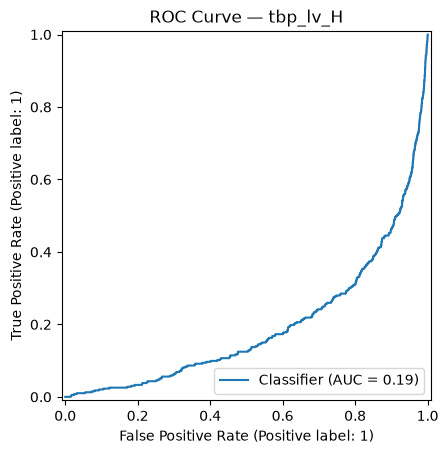

In [85]:
col = 'tbp_lv_H'

temp = train[['target', col]].dropna()

sklearn.metrics.RocCurveDisplay.from_predictions(
    temp['target'],
    temp[col]
)

plt.title(f'ROC Curve — {col}')
plt.show()

## Missing values and patients with cancer

In [88]:
train['age_approx'].isna().sum()

np.int64(2798)

In [90]:
(train.groupby('patient_id')['target'].sum() > 0).sum()

np.int64(259)